In [21]:
import statsmodels.api as sm
import pandas as pd

data = pd.read_csv(
    "/Users/eduardo/Desktop/Python_Coding/Applied-Data-Science-Classes/Machine Learning/Boston.csv",
    index_col=0,
 )
data.columns = data.columns.str.strip().str.upper()

In [22]:
print(data.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO       BLACK  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

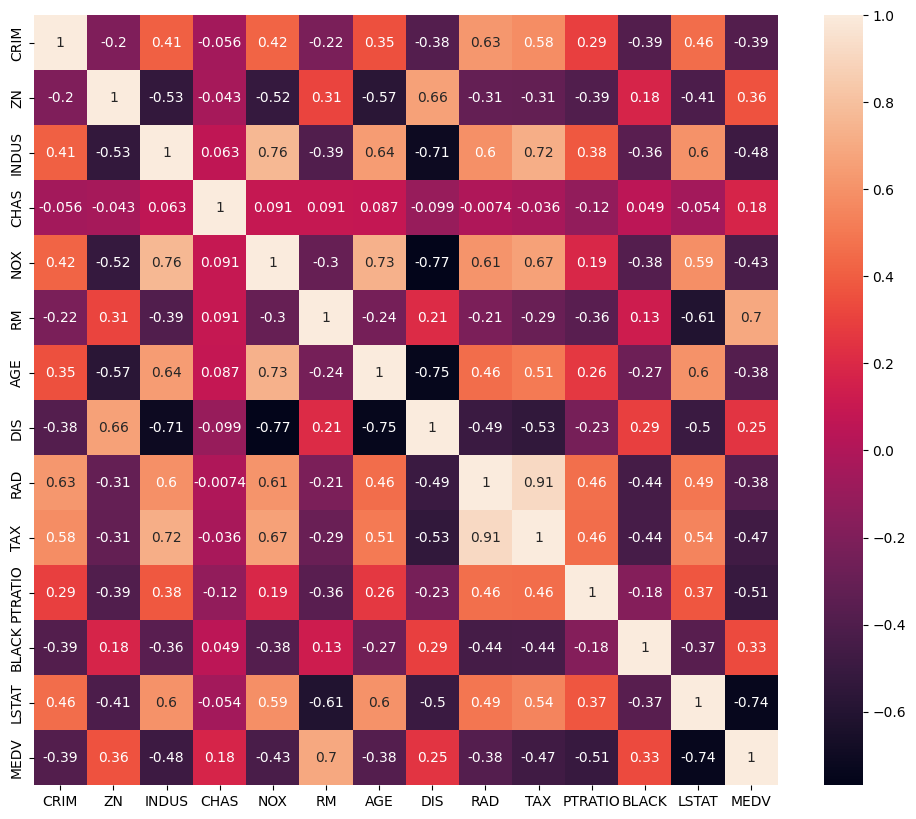

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True)
plt.show()

In [24]:
import numpy as np
import pandas as pd
# define the data/predictors as the pre-set feature names
df = pd.DataFrame(data, columns=data.columns)

# Put the target (housing value -- MEDV) in another DataFrame
target = pd.DataFrame(data, columns=["MEDV"])

In [25]:
## Without a constant

import statsmodels.api as sm

X = df["RM"]
y = target["MEDV"]

# Note the difference in argument order
model = sm.OLS(y, X).fit()
predictions = model.predict(X) # make the predictions by the model

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.901
Model:                            OLS   Adj. R-squared (uncentered):              0.901
Method:                 Least Squares   F-statistic:                              4615.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):                   3.74e-256
Time:                        14:53:39   Log-Likelihood:                         -1747.1
No. Observations:                 506   AIC:                                      3496.
Df Residuals:                     505   BIC:                                      3500.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
RM             3.6534      0.054     67.930      0.000       3.548       3.759
==============================================================================
Omnibus:                       83.295   Durbin-Watson:                   0.493
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.507
Skew:                           0.955   Prob(JB):                     7.65e-34
Kurtosis:                       4.894   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
import statsmodels.api as sm # import statsmodels

X = df["RM"] ## X usually means our input variables (or independent variables)
y = target["MEDV"] ## Y usually means our output/dependent variable
X = sm.add_constant(X) ## let's add an intercept (beta_0) to our model

# Note the difference in argument order
model = sm.OLS(y, X).fit() ## sm.OLS(output, input)
predictions = model.predict(X)

# Print out the statistics
model.summary()
#X = df[[“RM”, “LSTAT”]]
#y = target[“MEDV”]
#model = sm.OLS(y, X).fit()
#predictions = model.predict(X)
#model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.49e-74
Time:                        14:53:39   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.6706      2.650    -13.084      0.000     -39.877     -29.465
RM             9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
X = df[["RM", "LSTAT", "PTRATIO", "CRIM"]]
y = target["MEDV"]
model = sm.OLS(y, X).fit()
predictions = model.predict(X)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.953
Model:                            OLS   Adj. R-squared (uncentered):              0.953
Method:                 Least Squares   F-statistic:                              2542.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):                        0.00
Time:                        15:25:44   Log-Likelihood:                         -1559.8
No. Observations:                 506   AIC:                                      3128.
Df Residuals:                     502   BIC:                                      3144.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
RM             6.1741      0.225     27.446      0.000       5.732       6.616
LSTAT         -0.4496      0.042    -10.766      0.000      -0.532      -0.368
PTRATIO       -0.5586      0.091     -6.115      0.000      -0.738      -0.379
CRIM          -0.0910      0.031     -2.960      0.003      -0.151      -0.031
==============================================================================
Omnibus:                      222.478   Durbin-Watson:                   0.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1415.393
Skew:                           1.811   Prob(JB):                    4.48e-308
Kurtosis:                      10.349   Cond. No.                         24.9
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [66]:
from sklearn.preprocessing import StandardScaler

# Logistic regression with normalized predictors
predictor_cols = ["RM", "LSTAT", "PTRATIO", "CHAS", "NOX", "RAD", "DIS", "AGE"] 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[predictor_cols])
X_logit = pd.DataFrame(X_scaled, columns=predictor_cols, index=df.index)


# Set the MEDV cutoff here (change this value to redefine expensive vs cheap)
medv_threshold = target["MEDV"].median()

# Binary target for logistic regression: 1 = expensive, 0 = cheap
y_logit = (target["MEDV"] > medv_threshold).astype(int)

logit_model = sm.Logit(y_logit, X_logit).fit(disp=False)
logit_probabilities = logit_model.predict(X_logit)

# Convert class labels for readability
price_class = y_logit.map({1: "expensive", 0: "cheap"})

print(f"MEDV threshold: {medv_threshold:.2f}")
print(price_class.value_counts())
logit_model.summary()

MEDV threshold: 21.20
MEDV
cheap        256
expensive    250
Name: count, dtype: int64


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   MEDV   No. Observations:                  506
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            7
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.5788
Time:                        16:03:03   Log-Likelihood:                -147.70
converged:                       True   LL-Null:                       -350.70
Covariance Type:            nonrobust   LLR p-value:                 1.239e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RM             1.0279      0.260      3.951      0.000       0.518       1.538
LSTAT         -2.3972      0.348     -6.881      0.000      -3.080      -1.714
PTRATIO       -1.0869      0.205     -5.304      0.000      -1.488      -0.685
CHAS           0.5407      0.163      3.325      0.001       0.222       0.860
NOX           -0.9304      0.285     -3.268      0.001      -1.488      -0.372
RAD            0.5665      0.223      2.538      0.011       0.129       1.004
DIS           -1.1698      0.243     -4.814      0.000      -1.646      -0.694
AGE           -0.6742      0.275     -2.455      0.014      -1.212      -0.136
==============================================================================
"""

Linear Regression in SKLearn

In [28]:
from sklearn import linear_model

In [29]:
# Data is already loaded from Boston.csv in the first cell.
# Keeping this cell to avoid relying on deprecated sklearn datasets.
data = data.copy()

In [30]:
X = df
y = target["MEDV"]

In [31]:
lm = linear_model.LinearRegression()
model = lm.fit(X,y)

In [32]:
predictions = lm.predict(X)
print(predictions[0:5])

[24.  21.6 34.7 33.4 36.2]


In [33]:
lm.score(X,y)

1.0

In [34]:
lm.coef_

array([-2.11543805e-17,  4.78783679e-16,  7.83164583e-16, -1.95630723e-14,
        3.05029705e-15, -2.25661122e-15, -1.18660982e-16, -2.75692781e-16,
       -1.77678065e-16, -2.37406421e-17,  2.13107128e-16, -6.76581301e-17,
       -9.00763620e-17,  1.00000000e+00])

In [68]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler

# exclude target
X_fs = df.drop(columns=["MEDV"]) if "MEDV" in df.columns else df.copy()
y_fs = target["MEDV"]

# Normalize predictors 
scaler_fs = StandardScaler()
X_fs_scaled = scaler_fs.fit_transform(X_fs)

# Lasso: shrinks some coefficients exactly to zero 
lasso = LassoCV(cv=5, random_state=42).fit(X_fs_scaled, y_fs)
lasso_coef = pd.Series(lasso.coef_, index=X_fs.columns)
selected_lasso = lasso_coef[lasso_coef.abs() > 1e-6].sort_values(key=lambda s: s.abs(), ascending=False)

# Ridge: keeps all variables, rank by absolute coefficient magnitude
ridge = RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5).fit(X_fs_scaled, y_fs)
ridge_coef = pd.Series(ridge.coef_, index=X_fs.columns).sort_values(key=lambda s: s.abs(), ascending=False)

print(f"Lasso best alpha: {lasso.alpha_:.6f}")
print("Lasso selected variables:")
print(selected_lasso if not selected_lasso.empty else "No variables selected.")

print(f"\nRidge best alpha: {ridge.alpha_:.6f}")
print("Top Ridge variables (by |coefficient|):")
print(ridge_coef.head(10))

Lasso best alpha: 0.156573
Lasso selected variables:
LSTAT     -3.719773
RM         2.910917
DIS       -2.031603
PTRATIO   -1.846030
NOX       -1.307582
BLACK      0.712604
CHAS       0.643328
ZN         0.498623
CRIM      -0.465366
RAD        0.372050
TAX       -0.155778
INDUS     -0.074003
dtype: float64

Ridge best alpha: 94.378783
Top Ridge variables (by |coefficient|):
LSTAT     -2.991532
RM         2.786539
DIS       -1.732212
PTRATIO   -1.674800
NOX       -0.951253
BLACK      0.783101
CHAS       0.740892
RAD        0.734736
CRIM      -0.657705
TAX       -0.623093
dtype: float64
